In [197]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#1


In [198]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

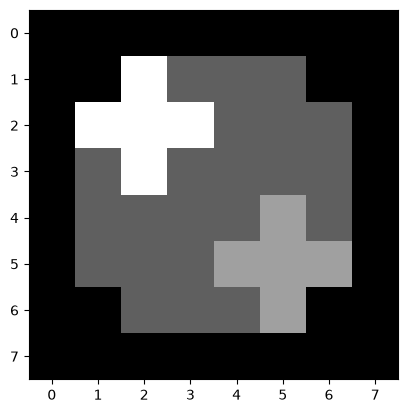

In [199]:
#A
x= plt.imshow(X_fantoma, cmap="gray")

In [200]:
#B
x_fantoma= X_fantoma.reshape(-1)
x_fantoma

array([0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.8, 0.3, 0.3,
       0.3, 0. , 0. , 0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. , 0. , 0.3,
       0.8, 0.3, 0.3, 0.3, 0.3, 0. , 0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3,
       0. , 0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. , 0. , 0. , 0.3, 0.3,
       0.3, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

In [201]:
#C
X_temp=[]
i=0
j=0
z=0
while(i<8):
    temp = []
    while(j<8):
        temp.append(x_fantoma[z])
        j+=1
        z+=1
    j=0
    X_temp.append(temp)
    i+=1


X_fantoma_recon = np.array(X_temp,dtype=float)
X_fantoma_recon

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.8, 0.3, 0.3, 0.3, 0. , 0. ],
       [0. , 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0. ],
       [0. , 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0. ],
       [0. , 0. , 0.3, 0.3, 0.3, 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

D
el valor de una compente x_k es el coeficiente de atenuidad recibida por los receptores a la hora de emitir los rayos x al realizar la tomografía, se considera una atenuidad alta (se recibe poca informacion de rayos x) a valores cercanos a 1, mientras que por el contrario se considera una atenuidad baja a los valores cercanos a 0 (se recibe en gran cantidad la informacion eviada por los rayos x), en esta imagen podemos notar como en los pixeles centrales se recibe menos información.
**escrito asi nomas, despues hay q reescribir**

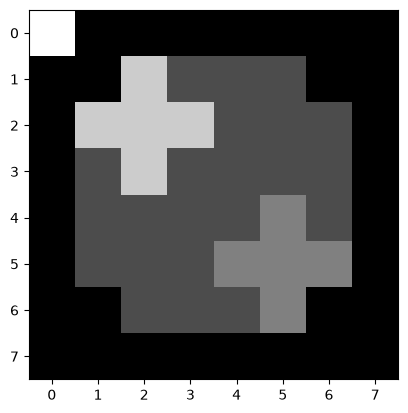

In [202]:
X_fantoma_mod = np.array([
[1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x= plt.imshow(X_fantoma_mod, cmap="gray")


en el vector x_fantona cambia el pixel x_0
i x 8 : cuantas filas me tengo que mover desde la fila 0 para llegar a la fila donde a la que pertenece el pixel (i,j) 
j : parandome en el primer elemento de la fila a la que pertenece el pixel, a que columna me debo mover.


#2

In [203]:
#a
def mascara_rayo(n, direccion, s):
    M = np.zeros((n, n), dtype=int)
    i=0
    while(i<len(M)):
        j=0
        while j < len(M[i]):
            if direccion[0]*i + direccion[1]*j == s:
                M[i][j] = 1
            j+=1
        i+=1

    return M


In [204]:
#b
A= mascara_rayo(8,(1,0),3)
B= mascara_rayo(8,(0,1),5)
C= mascara_rayo(8,(1,1),7)
D= mascara_rayo(8,(1,-1),0)
E= mascara_rayo(8,(2,1),8)

In [205]:
A

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [206]:
B

array([[0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0]])

In [207]:
C

array([[0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0]])

In [208]:
D

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [209]:
E

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

In [210]:
def medicion_br(X_Fantoma, M_r):
    i=0
    br=0
    while(i < len(X_Fantoma)): #sabiendo que la matriz fantoma es de 8x8 al igual que M_r
        j=0
        while(j < len(X_Fantoma[0])):
            br += M_r[i][j] * X_Fantoma[i][j]
            j+=1
        j=0
        i+=1
    return br
result = medicion_br(X_fantoma, A)
result


np.float64(2.3)

## 3A y 3B

In [211]:
def matriz_proyeccion(n,direcciones):
    Matriz_resultado = [] #matriz con todos todos los rayos proyectados en filas
    lista_direccion_s = []
    for direccion in direcciones: #recorremos todas las direcciones
        res =  [] #guardamos los valores de s de cada direccion (α,β)
        i=0
        while i < n: #recorremos filas
            j=0
            while j < n: #recorremos columnas 
                s = direccion[0]*i + direccion[1]*j   #formula para calcular rayo
                res.append(s)       #guardamos los s
                j+=1
            i+=1
        valores_s = sorted(set(res))        #eliminamos los s repetidos y ordenamos de menor a mayor
        for s in valores_s:     #recorremos los s de por cada (α,β)
            lista_direccion_s.append((direccion,s))
            mascara = mascara_rayo(n, direccion, s)     #generamos la mascara del rayo generado por cada s
            proyeccion = mascara.reshape(-1)            #lo ponemos como una unica fila
            Matriz_resultado.append(proyeccion)         #agregamos a la matriz final
    return Matriz_resultado, lista_direccion_s

## 3C

In [212]:
resultado_lista = matriz_proyeccion(8, [[1,0],[0,1]])[1]
A = matriz_proyeccion(8, [[1,0],[0,1]])[0]

longitud_lista = len(resultado_lista) # miramos cuantos ((α, β), s) hay en total
longitud_matriz = (len(A), len(A[0])) #tomamos la longitud de la matriz

print("Rayos obtenidos:", longitud_lista)
print("Dimension de la matriz :", longitud_matriz)

Rayos obtenidos: 16
Dimension de la matriz : (16, 64)


## 3D



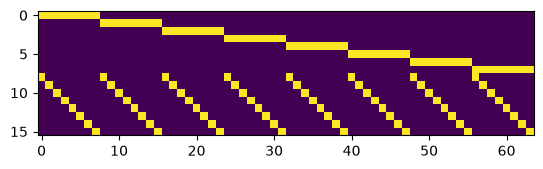

In [213]:
# cada fila representa a un rayo (su matriz de representacion aplanada en una fila)
# cada columan representa a un pixel de la imagen.
# A[r][j] = 1 si el rayo "r" pasa por el centro del pixel j.
# es logico que la matriz resultante tenga mayor cantidad de ceros, ya que solo tendra un valor distinto (1) 
# si el rayo pasa por el centro del pixel (o cambiarlo a que cada fila tiene un solo rayo entonces hay muchos ceros)
plt.imshow(A)


## 3E

In [214]:
b = A @ x_fantoma #b: 
X_fantoma_sum_1 = X_fantoma.sum(axis=1) #suma todos los elementos de la fila 1 => la acumulacion de atenuacion
X_fantoma_sum_0 = X_fantoma.sum(axis=0)

primer_comparacion = np.allclose(b[:8], X_fantoma_sum_1) 
segunda_comparacion = np.allclose(b[8:], X_fantoma_sum_0)
res = (primer_comparacion == segunda_comparacion)
res
#vemos que coinciden

True

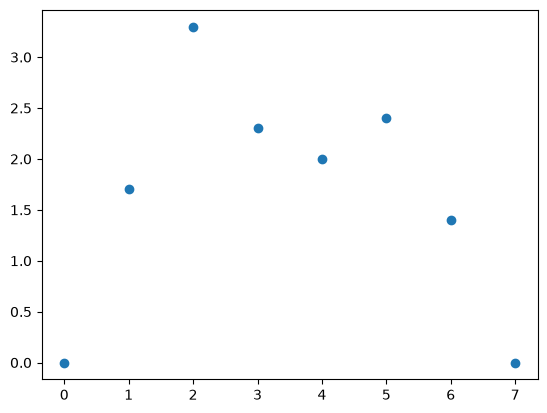

In [215]:
#Graficamos:
plt.plot(X_fantoma_sum_0, 'o') #preguntar si conceptualmente estan bien los puntos
plt.show()


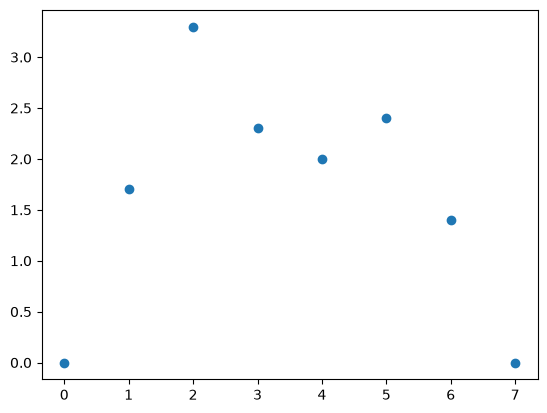

In [216]:
plt.plot(X_fantoma_sum_1, 'o')
plt.show()

# 4A

para que una imagen pueda reconstruirse de manera unica, Ax=b debe tener una unica solución, si existe algun vector Av=0 podríamos obtener la reconstruccion "b" como A(x+v) ya que Ax+Av= b, es decir no se podría reconstruir de manera unica, por este motivo no puede haber nigun vector que cumpla Av=0, por ende la dimension de nulidad debe ser vacia, utilizando el teorema de rango y nulidad sabemos rango(A)+dim(Nul(A))=N, con lo ya mencionado y sabiendo que la cantidad de columnas de la matriz "A" es de 64, rango(A)=64 para que la imagen pueda reconstruirse de manera única.

# 4B

In [217]:
A2 = np.array(matriz_proyeccion(8, [[1,0],[0,1]])[0])
A4 = np.array(matriz_proyeccion(8, [[1,0],[0,1],[1,1],[1,-1]])[0])
A7 = np.array(matriz_proyeccion(8, [[1,0],[0,1],[1,1],[1,-1],[2,1],[1,2],[3,1]])[0])

for nombre, A in [("A2", A2), ("A4", A4), ("A7", A7)]:
    filas, columnas = A.shape
    rango = np.linalg.matrix_rank(A)
    dim_nulo = columnas - rango

    print(nombre)
    print("Dimensiones:", A.shape)
    print("Rango:", rango)
    print("Dimensión del espacio nulo:", dim_nulo)
    print("Imagen única:", dim_nulo == 0)
    print("Mediciones redundantes:", filas - rango)
    print()

A2
Dimensiones: (16, 64)
Rango: 15
Dimensión del espacio nulo: 49
Imagen única: False
Mediciones redundantes: 1

A4
Dimensiones: (46, 64)
Rango: 39
Dimensión del espacio nulo: 25
Imagen única: False
Mediciones redundantes: 7

A7
Dimensiones: (119, 64)
Rango: 64
Dimensión del espacio nulo: 0
Imagen única: True
Mediciones redundantes: 55



falta poner la comparacion entre rango y fila, y de  ultima explicar el por que se da lo de que no se reconstruye de manera unica.

In [218]:
U, s, Vt = np.linalg.svd(A4)
min(s)

np.float64(4.654459528758201e-16)

vemos que el valor singular mas chico es 4.654459528758201e-16 correspondiente a la ultima fila de Vt ya que estan ordenados de mayor a menor. Utilizamos solo un vector ya que el enunciado pide uno.

In [219]:
#obtenemos el vector en la ultima fila
V4 = Vt[-1]
#chequeamos que A*vector ≈ 0
resultado = A4 @ V4
resultado

array([ 2.22044605e-16, -1.66533454e-16, -3.33066907e-16, -9.71445147e-17,
       -2.77555756e-17,  0.00000000e+00, -2.63677968e-16, -2.08166817e-16,
       -4.16333634e-17, -2.77555756e-16, -2.49800181e-16, -3.60822483e-16,
        2.22044605e-16, -6.93889390e-17, -9.71445147e-17,  1.11022302e-16,
        9.40252840e-17,  8.67361738e-18, -5.20417043e-18, -2.84494650e-16,
        5.55111512e-17, -1.66533454e-16,  2.42861287e-17, -2.22044605e-16,
       -1.11022302e-16,  6.93889390e-17, -2.18575158e-16, -1.66533454e-16,
        5.55111512e-17,  1.11022302e-16,  0.00000000e+00, -4.85722573e-17,
        6.24500451e-17,  0.00000000e+00,  8.32667268e-17, -2.77555756e-17,
        1.66533454e-16, -8.32667268e-17, -3.46944695e-16,  2.77555756e-17,
       -8.32667268e-17, -3.19189120e-16,  2.22044605e-16, -1.52655666e-16,
       -2.22044605e-16, -1.38777878e-17])

vemos que todos los valores son cercanos a cero, verificamos con la norma (∥A4v∥ ≈ 0)

In [220]:
np.linalg.norm(resultado)

np.float64(1.1565543928271298e-15)

In [221]:
#calculamos b4
γ = 1
b4 = A4 @ x_fantoma
x_alt = x_fantoma + γ*V4
b4_alt = A4 @ x_alt
#vemos si son parecidas
parecido = np.linalg.norm(b4 - b4_alt)
parecido

np.float64(1.5936471731475977e-15)

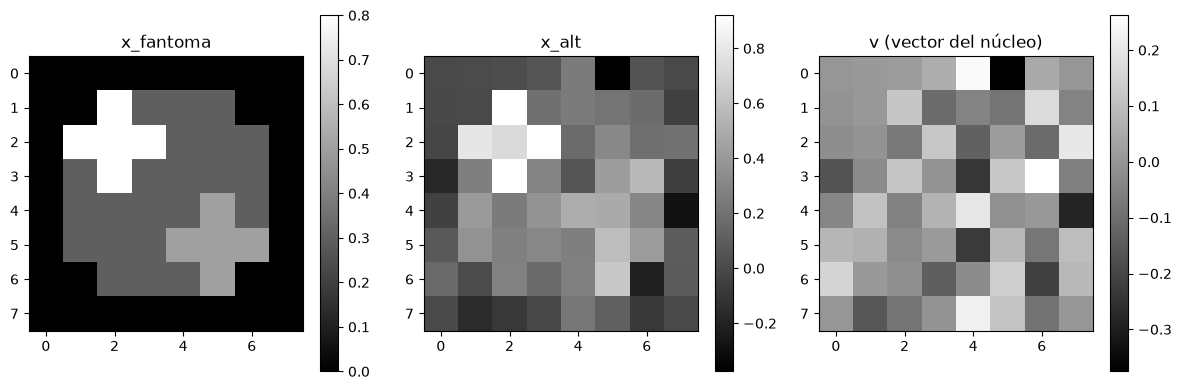

In [222]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

im0 = axs[0].imshow(x_fantoma.reshape(8, 8), cmap='gray')
axs[0].set_title('x_fantoma')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(x_alt.reshape(8, 8), cmap='gray')
axs[1].set_title('x_alt')
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(V4.reshape(8, 8), cmap='gray')
axs[2].set_title('v (vector del núcleo)')
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

podemos notar que dan mediciones bastante similares (un parecido de 1.5936471731475977e-15), a pesar de como podemos notar en la imagen las claras diferencias que tienen.

5a

In [223]:
b2 = A2 @ x_fantoma
b4 = A4 @ x_fantoma
b7 = A7 @ x_fantoma

x_2, _, _, _ = np.linalg.lstsq(A2, b2, rcond=None)
x_4, _, _, _ = np.linalg.lstsq(A4, b4, rcond=None)
x_7, _, _, _ = np.linalg.lstsq(A7, b7, rcond=None)

b

In [224]:
residuo2 = b2 - A2 @ x_2
residuo4 = b4 - A4 @ x_4
residuo7 = b7 - A7 @ x_7

norma2 = np.linalg.norm(residuo2)
norma4 = np.linalg.norm(residuo4)
norma7 = np.linalg.norm(residuo7)

In [225]:
error_relativo2 = np.linalg.norm( x_2 - x_fantoma) / np.linalg.norm(x_fantoma)
error_relativo4 = np.linalg.norm( x_4 - x_fantoma) / np.linalg.norm(x_fantoma)
error_relativo7 = np.linalg.norm( x_7 - x_fantoma) / np.linalg.norm(x_fantoma)


tabla = pd.DataFrame({
    'rango': [np.linalg.matrix_rank(A2), np.linalg.matrix_rank(A4), np.linalg.matrix_rank(A7)],
    'norma_residuo': [norma2, norma4, norma7],
    'error_relativo': [error_relativo2, error_relativo4, error_relativo7]
}, index=['A2', 'A4', 'A7'])
tabla

,rango,norma_residuo,error_relativo
A2,15,3.398698e-15,4.689265e-01
A4,39,1.016940e-14,1.364605e-01
A7,64,1.416855e-14,2.188251e-15


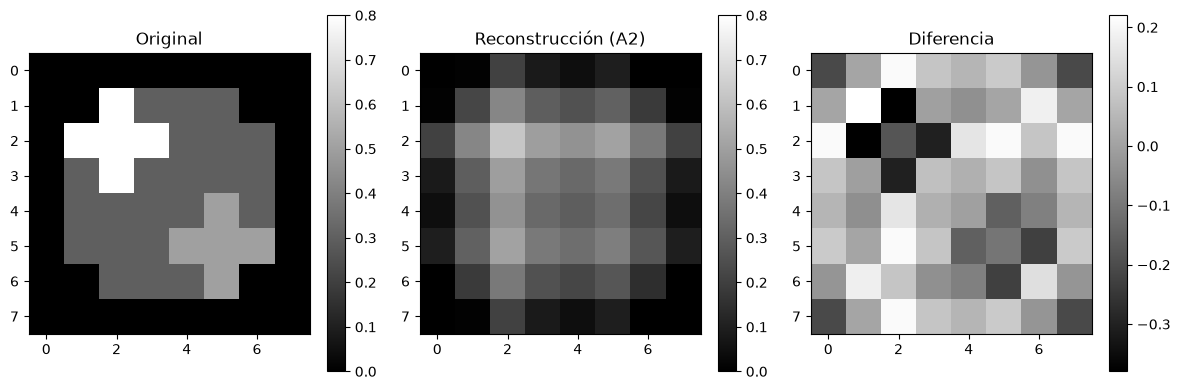

In [226]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

vmin, vmax = 0, 0.8  # rango de x_fantoma

im0 = axs[0].imshow(x_fantoma.reshape(8, 8), cmap='gray', vmin=vmin, vmax=vmax)
axs[0].set_title('Original')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(x_2.reshape(8, 8), cmap='gray', vmin=vmin, vmax=vmax)
axs[1].set_title('Reconstrucción (A2)')
plt.colorbar(im1, ax=axs[1])

diferencia = (x_2 - x_fantoma).reshape(8, 8)
im2 = axs[2].imshow(diferencia, cmap='gray')
axs[2].set_title('Diferencia')
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

La reconstrucción x̂ minimiza el residuo ‖Akx̂ − b‖, pero no necesariamente coincide con xfantoma. Si Ak no tiene rango completo, existe v≠0 con Akv=0 (espacio nulo no trivial), y entonces para cualquier γ. por ejemplo, con k=2. A_2*(x_2 + γ*v ) = A_2*x_2+ A_2*(γ*v) = A_2*x_2.

Por lo tanto, sumarle a x̂ cualquier múltiplo de v no cambia el residuo, aunque la imagen resultante sea distinta.